In [1]:
from google.colab import files
uploaded = files.upload()

Saving IRIS[1].csv to IRIS[1].csv


In [2]:
import pandas as pd

df = pd.read_csv("IRIS[1].csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

Dataset Shape:
(150, 5)

First 5 Rows:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [3]:
print(df.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [4]:
print(df.describe())

print("\nSpecies Count:")
print(df["species"].value_counts())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

Species Count:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


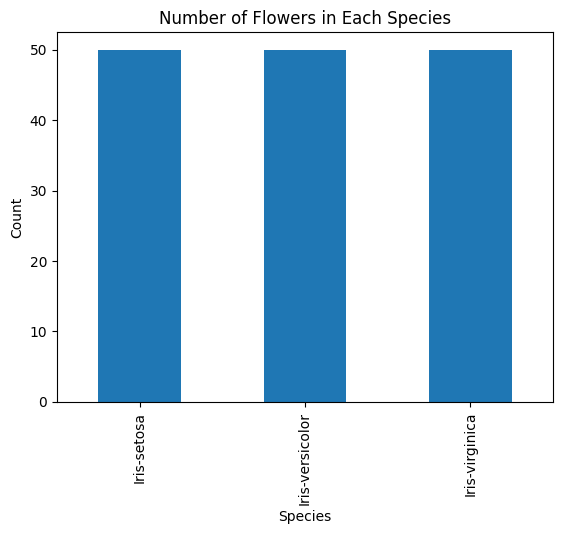

In [5]:
import matplotlib.pyplot as plt

df["species"].value_counts().plot(kind="bar")

plt.title("Number of Flowers in Each Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

In [6]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["species"] = encoder.fit_transform(df["species"])

X = df.drop("species", axis=1)
y = df["species"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [10]:
result = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": predictions[:10]
})

print(result)

   Actual  Predicted
0       1          1
1       0          0
2       2          2
3       1          1
4       1          1
5       0          0
6       1          1
7       2          2
8       1          1
9       1          1
